<a href="https://colab.research.google.com/github/emioliva85/herramientasbasicas-oliva-emilia/blob/main/Trabajo_Integrador_Final_OLIVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Trabajo Integrador Final**

### **Análisis estadístico de la mediación prejudicial y judicial en Argentina: Un estudio basado en el Sistema MEPRE (2014-2015)**

##**Marco de Datos y Origen**
####Se utilizó un conjunto de datos (dataset) proveniente del portal oficial del Ministerio de Justicia de la Nación. El corpus de datos comprende el registro de mediaciones prejudiciales y judiciales —en el marco de la Ley 26.589— gestionadas a través del Sistema MEPRE desde febrero de 2014 hasta octubre de 2024.


##**Objetivos del Análisis**
El presente trabajo se propone alcanzar los siguientes objetivos:

####**Análisis Temporal**: Evaluar la evolución del acceso al recurso de mediación a lo largo del tiempo, identificando tendencias o variaciones en el ingreso de las causas.

####**Identificación de Materias**: Cuantificar y categorizar el objeto de los reclamos con el fin de determinar las áreas o temáticas que concentran el mayor volumen de litigiosidad.

####**Caracterización del Proceso**: Examinar variables críticas como el tipo de mediación (pública o privada), el estado actual de las actuaciones, el resultado final de las audiencias y la densidad procesal (cantidad de audiencias por caso).

####**Análisis de Resolución y Efectividad**: Determinar el resultado final de las audiencias, con especial énfasis en verificar el porcentaje de cierres con acuerdo, a fin de medir la eficacia de la instancia de mediación como método de resolución de conflictos.


## **Metodología y Herramientas de Procesamiento**
Para el tratamiento, limpieza y visualización de los datos, se optó por un entorno de programación basado en la nube y librerías de código abierto de alto rendimiento:

####**Entorno de desarrollo**: Se utilizó **Google Colab**, una plataforma que permite la ejecución de código en la nube, garantizando la trazabilidad de cada etapa del análisis y facilitando la reproducibilidad de los resultados.

####**Manipulación de datos**: La librería **Pandas** fue el eje central para la estructuración del dataset. Se aplicaron funciones de filtrado, imputación de valores faltantes y segmentación temporal para transformar los registros crudos en información analizable.

####**Procesamiento numérico y lógico**: Se empleo la librería **NumPy** como base para las operaciones vectorizadas y el manejo eficiente de estructuras de datos. Su uso fue clave para la identificación y tratamiento técnico de valores nulos y para la realizar cálculos estadisticos avanzados sobre las variables de densidad procesal.

####**Visualización estadística**: Con el fin de identificar patrones y tendencias de manera intuitiva, se emplearon las librerías **Matplotlib** y **Seaborn**. Estas herramientas permitieron la creación de histogramas, gráficos de dispersión y diagramas de caja (boxplots) para representar la distribución de las mediaciones y sus resultados.


#####Este trabajo fue realizado por OLIVA Emilia – DNI 31839721

####**Importació de Dataset**

In [ ]:
#El dataset se importa al entorno de ejecución desde un almacenamiento local
ruta_real = "/mediaciones-prejudiciales-y-judiciales-202603.csv"

df = pd.read_csv(ruta_real, encoding='latin-1', sep=None, engine='python')

####**Importación de Librerías**

In [ ]:
#Librerías para manejo y depuración de datos
import pandas as pd
import numpy as np

#Librerías para visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

###**Exploración de Datos**

####La fase de exploración permite auditar la calidad de la información y entender la estructura del dataset antes de realizar cualquier cálculo.

####**Dimensiones del Dataset**

In [ ]:
# Devuelve la cantidad total de filas y columnas (Estructura: [filas, columnas]).

print(df.shape)

(1048575, 12)


####**Análisis de Tipos de Datos y Completitud**

In [ ]:
#Análisis de Tipos de Datos y Completitud
# Proporciona un resumen técnico: nombres de columnas, tipos de datos (int64, object)
# y detección de valores nulos (celdas vacías).

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 12 columns):
 #   Column                  Non-Null Count    Dtype 
---  ------                  --------------    ----- 
 0   ï»¿fuero                1048575 non-null  object
 1   mediacion               1048575 non-null  int64 
 2   tipo_de_mediacion       1048575 non-null  object
 3   estado                  1048575 non-null  object
 4   reapertura              1048575 non-null  object
 5   fecha_de_inicio         1048575 non-null  object
 6   objeto                  1048575 non-null  object
 7   honorarios_pagos        1048575 non-null  object
 8   mediador                1048575 non-null  int64 
 9   resultado_mediacion     893538 non-null   object
 10  cantidad_de_audiencias  1048575 non-null  int64 
 11  fecha_ultima_audiencia  956195 non-null   object
dtypes: int64(3), object(9)
memory usage: 96.0+ MB


###**Resumen Estadístico**

In [ ]:
# Calcula las métricas descriptivas para las columnas numéricas:
# tendencia central (promedio, mediana), dispersión (desviación estándar) y valores extremos (mín/máx).

df.describe()

,mediacion,mediador,cantidad_de_audiencias
count,1.048575e+06,1.048575e+06,1.048575e+06
mean,6.894541e+05,1.071839e+03,1.528469e+00
std,4.450686e+05,6.245296e+02,2.867593e+01
min,3.000000e+01,1.260000e+02,0.000000e+00
25%,3.040875e+05,6.050000e+02,1.000000e+00
50%,6.323460e+05,9.140000e+02,1.000000e+00
75%,1.083372e+06,1.395000e+03,2.000000e+00
max,1.709530e+06,3.727000e+03,9.800000e+03


###**Limpieza de Datos**
####Proceso de detección y corrección de anomalías, registros duplicados o valores inconsistentes para garantizar la integridad del análisis.


In [ ]:
# Conteo de valores nulos por cada columna print("Valores faltantes por columna:")

print(df.isnull().sum())

ï»¿fuero                       0
mediacion                      0
tipo_de_mediacion              0
estado                         0
reapertura                     0
fecha_de_inicio                0
objeto                         0
honorarios_pagos               0
mediador                       0
resultado_mediacion       155037
cantidad_de_audiencias         0
fecha_ultima_audiencia     92380
dtype: int64


In [ ]:
# Verificación de filas duplicadas

print(f"\nCantidad de filas duplicadas: {df.duplicated().sum()}")


Cantidad de filas duplicadas: 0


In [ ]:
#Estandarización de Fechas
#Convertimos a formato datetime y eliminamos posibles errores

df['fecha_de_inicio'] = pd.to_datetime(df['fecha_de_inicio'], errors='coerce')
df['fecha_ultima_audiencia'] = pd.to_datetime(df['fecha_ultima_audiencia'], errors='coerce')

In [ ]:
#Estandarizacicón de Unidades (Númericas)
#Aseguramos que la cantidad de audiencias sea un número entero

df['cantidad_de_audiencias'] = pd.to_numeric(df['cantidad_de_audiencias'], errors='coerce')


In [ ]:
#Estandarizacicón de Categorías (Texto)
#Pasamos a mayúsculas, quitamos espacios extras y normalizamos tildes.

#Limpia los nombres de todas las columnas (quita caracteres raros y espacios)
df.columns = df.columns.str.replace('ï»¿', '').str.strip()

###**Resultado**
####Se detectaron valores nulos en los indicadores “resultado_mediacion” y “fecha_ultima_audiencia”. Con respecto al valor “resultado_mediacion” quedaran vacíos los que no hayan finalizado aún. Pero debemos corregir el valor “fecha_ultima_audiencia” y colocarle el mismo valor que “fecha_de_inicio”


In [ ]:
# base de datos de caracteres Unicode
import unicodedata

# Función que protege el "vacío" (nulo)
def normalizar_tildes(valor):
    #Si la celda no tiene dato (es nula), la devolvemos tal cual
    if pd.isna(valor):
        return valor

    #Si la celda TIENE dato, procedemos con la limpieza
    texto = str(valor).upper().strip()
    return unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')

# Limpieza preventiva de nombres de columnas (por el ï»¿)
df.columns = df.columns.str.replace('ï»¿', '').str.strip()

# Aplicamos solo a las columnas de texto de tu TIF
columnas_texto = ['fuero', 'tipo_de_mediacion', 'estado', 'objeto', 'resultado_mediacion']

for col in columnas_texto:
    if col in df.columns:
        print(f"Normalizando texto en: {col}")
        # .map aplica la función respetando los nulos originales
        df[col] = df[col].map(normalizar_tildes)

print("\n¡Proceso finalizado!")
#Verificamos que las celdas sin dato sigan estando ahí
print("Conteo de celdas vacías (nulos) por columna:")
print(df[columnas_texto].isna().sum())

Normalizando texto en: fuero
Normalizando texto en: tipo_de_mediacion
Normalizando texto en: estado
Normalizando texto en: objeto
Normalizando texto en: resultado_mediacion

¡Proceso finalizado!
Conteo de celdas vacías (nulos) por columna:
fuero                       0
tipo_de_mediacion           0
estado                      0
objeto                      0
resultado_mediacion    155037
dtype: int64


In [ ]:
# Comprobación de resultados: Validación de registros corregidos en 'fecha_ultima_audiencia'.

print(df.isnull().sum())

fuero                          0
mediacion                      0
tipo_de_mediacion              0
estado                         0
reapertura                     0
fecha_de_inicio                0
objeto                         0
honorarios_pagos               0
mediador                       0
resultado_mediacion       155037
cantidad_de_audiencias         0
fecha_ultima_audiencia         0
dtype: int64


###**Análisis Temporal**

In [ ]:
#Entraemos el año
df['año_inicio'] = df['fecha_de_inicio'].dt.year

#Contamos la cantidad de mediaciones por año
mediaciones_por_año = df['año_inicio'].value_counts(dropna=False).sort_index()


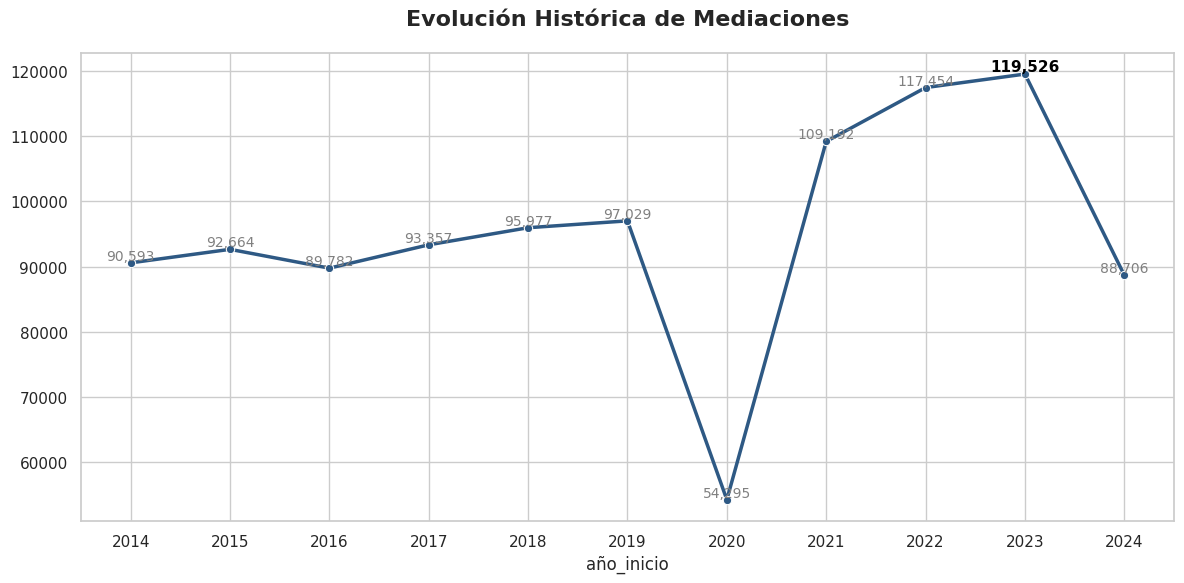

In [ ]:
# Identificamos el valor máximo para resaltarlo
valor_maximo = tendencia.max()

# Configuración visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.lineplot(x=tendencia.index, y=tendencia.values, marker='o', color='#2E5984', linewidth=2.5)

# Personalización y etiquetas condicionales
plt.title('Evolución Histórica de Mediaciones', fontsize=16, fontweight='bold', pad=20)
plt.xticks(tendencia.index.astype(int))

# Recorremos los puntos para poner las etiquetas
for x, y in zip(tendencia.index, tendencia.values):
    if y == valor_maximo:
        # Solo el máximo va en negrita y quizás un poquito más arriba
        plt.text(x, y, f'{int(y):,}', color='black', ha='center', va='bottom',
                 fontweight='bold', fontsize=11)
    else:
        # El resto va con peso normal
        plt.text(x, y, f'{int(y):,}', color='gray', ha='center', va='bottom',
                 fontweight='normal', fontsize=10)

plt.tight_layout()
plt.show()



> ###**Composición de Fueros**



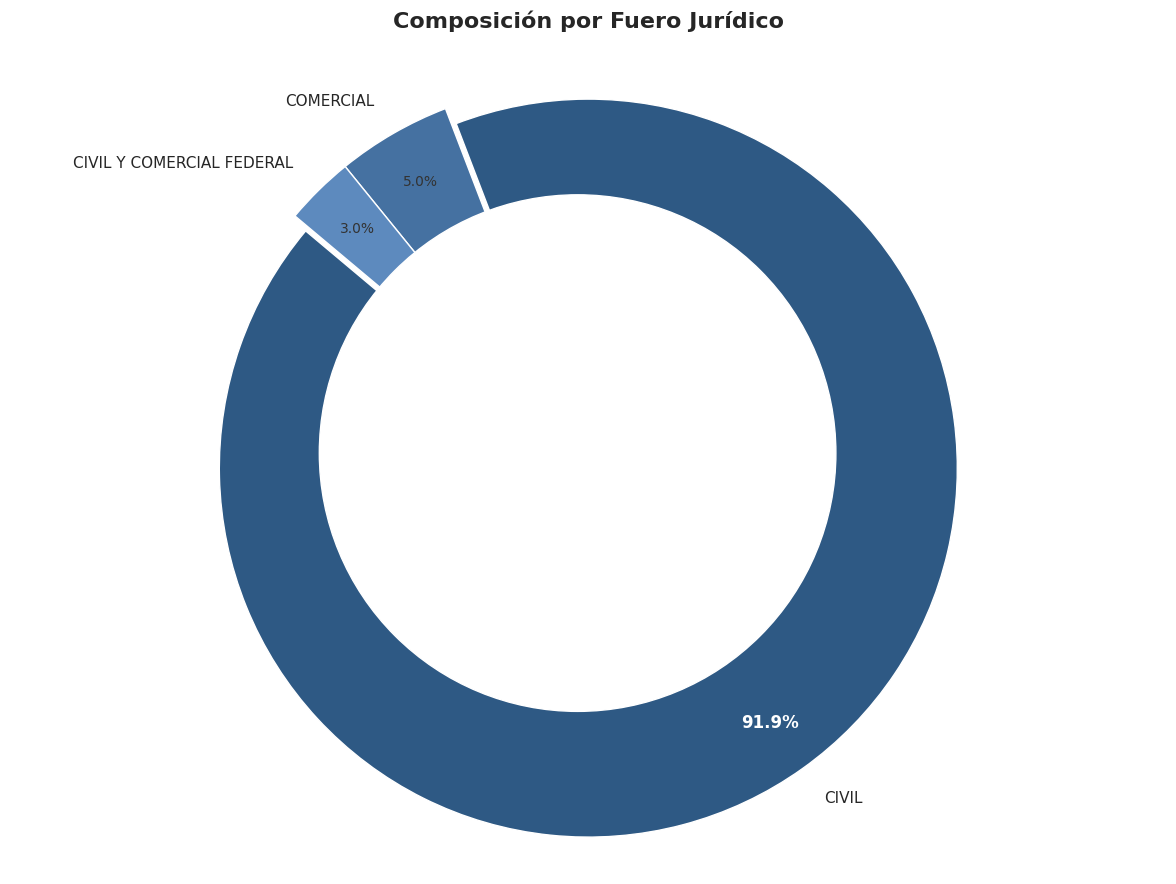

Total de categorías visualizadas: 3


In [ ]:
#VALIDACIÓN: Buscamos la columna de fuero
col_fuero = [c for c in df.columns if 'fuero' in c.lower()]

if not col_fuero:
    print("No se encontró la columna de fuero. Columnas disponibles:", df.columns.tolist())
else:
    nombre_col_fuero = col_fuero[0]

    # PREPARACIÓN DE DATOS (Sin agrupar "Otros")
    # Contamos frecuencias y eliminamos nulos para la visualización
    datos_grafico = df[nombre_col_fuero].dropna().value_counts()

    # CONFIGURACIÓN DE COLORES COHERENTES
    # Usamos el azul principal (#2E5984) y variantes de la misma gama
    colores_identidad = [
        '#2E5984', # Azul Principal (Máximo)
        '#4571A1',
        '#5D8ABE',
        '#76A3DB',
        '#8EBDF8',
        '#A7D6FF',
        '#C0EFFF'
    ]

    # CREACIÓN DEL GRÁFICO (Formato Dona)
    plt.figure(figsize=(12, 9))

    # Definimos el 'explode' para resaltar solo la porción más grande
    explode_lista = [0.05 if i == 0 else 0 for i in range(len(datos_grafico))]

    patches, texts, autotexts = plt.pie(
        datos_grafico.values,
        labels=datos_grafico.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colores_identidad[:len(datos_grafico)],
        pctdistance=0.85,
        explode=explode_lista
    )

    # ESTÉTICA PROFESIONAL Y UNIFICADA
    plt.title('Composición por Fuero Jurídico', fontsize=16, fontweight='bold', pad=25)

    # Ajuste de etiquetas de porcentaje para legibilidad
    for i, a_text in enumerate(autotexts):
        if i == 0: # El valor máximo (Azul fuerte) con texto blanco y negrita
            a_text.set_fontweight('bold')
            a_text.set_color('white')
            a_text.set_fontsize(12)
        else:
            a_text.set_color('#333333')
            a_text.set_fontsize(10)

    # Convertimos en formato dona
    centro_circulo = plt.Circle((0,0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centro_circulo)

    plt.axis('equal')
    plt.tight_layout()
    plt.show()

    # 6. RESUMEN DE CONTROL
    print(f"Total de categorías visualizadas: {len(datos_grafico)}")

###**Análisis de los Conflictos Ingresados al Sistema MEPRE**

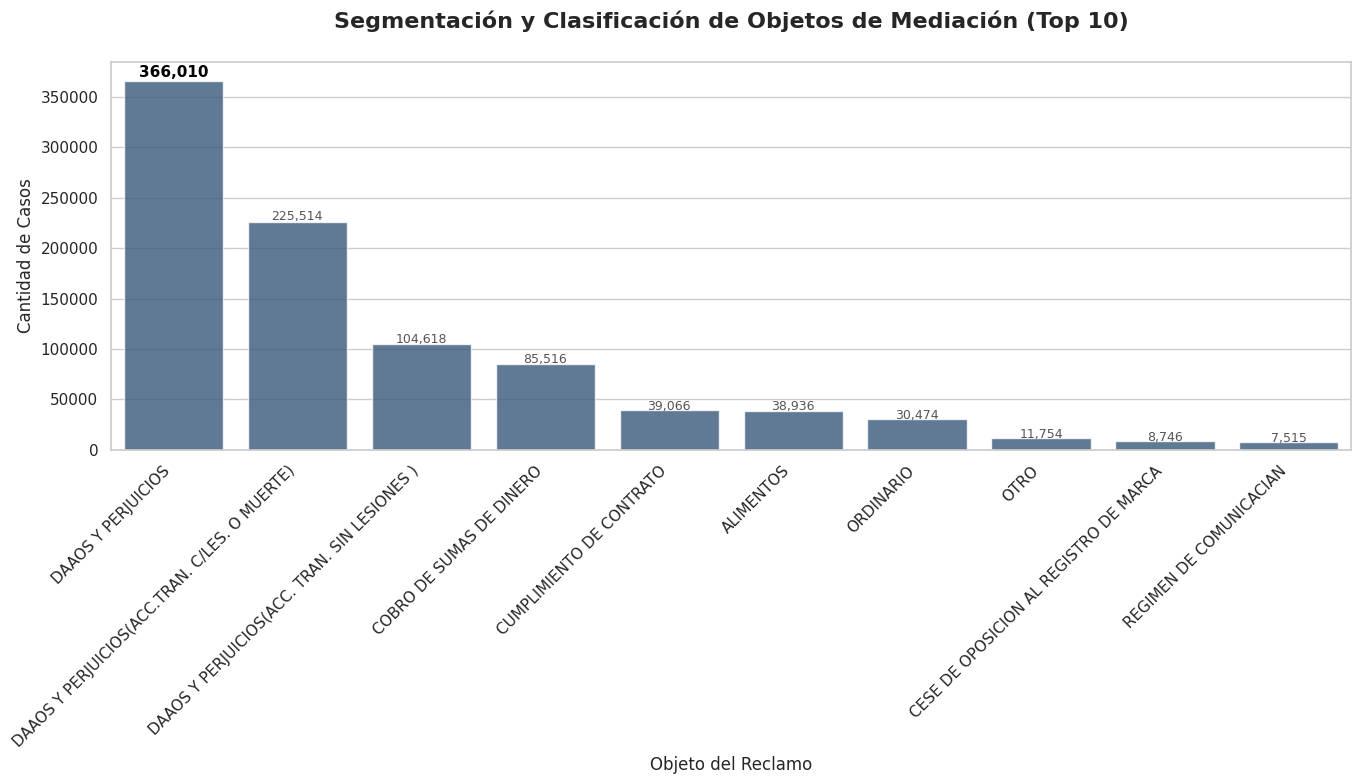

In [ ]:
# Preparación de datos (Top 10 Objetos para que el gráfico sea legible)
# Usamos el top 10 porque "Objeto" suele tener cientos de variantes
conteo_objetos = df['objeto'].value_counts().head(10)
valor_maximo = conteo_objetos.max()

# Configuración estética
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# Creación del gráfico de barras verticales (Ejes invertidos)
# x = Categorías (Objeto), y = Cantidad
ax = sns.barplot(x=conteo_objetos.index, y=conteo_objetos.values, color='#2E5984', alpha=0.8)

# 4. Título y etiquetas profesionales
plt.title('Segmentación y Clasificación de Objetos de Mediación (Top 10)', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Objeto del Reclamo', fontsize=12)
plt.ylabel('Cantidad de Casos', fontsize=12)

# Rotación de etiquetas en el eje X para que se lean bien
plt.xticks(rotation=45, ha='right')

# Etiquetas de datos condicionales (Negrita solo al máximo)
for i, v in enumerate(conteo_objetos.values):
    if v == valor_maximo:
        # El valor más alto resaltado
        ax.text(i, v + (v * 0.01), f'{int(v):,}',
                color='black', ha='center', fontweight='bold', fontsize=11)
    else:
        # El resto con formato normal
        ax.text(i, v + (v * 0.01), f'{int(v):,}',
                color='#555555', ha='center', fontweight='normal', fontsize=9)

plt.tight_layout()
plt.show()

###**Análisis de Tipos de Mediaciones**

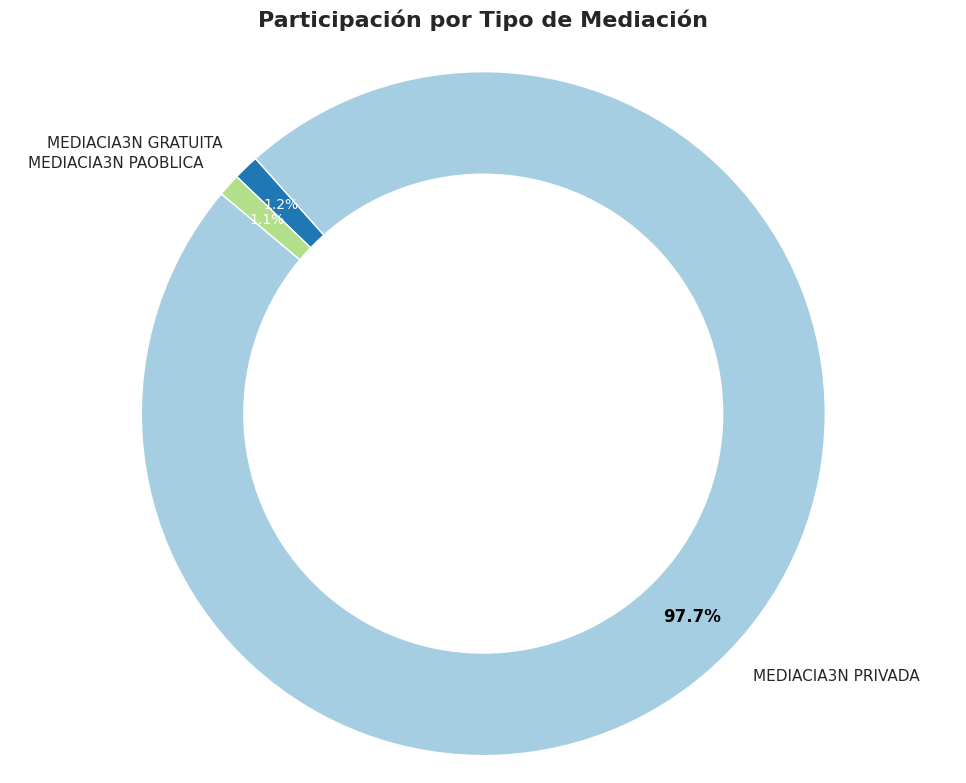

In [ ]:
# 1. Preparación de datos
conteo_tipos = df['tipo_de_mediacion'].value_counts()
labels = conteo_tipos.index
values = conteo_tipos.values
max_val = values.max()

# 2. Configuración del gráfico
plt.figure(figsize=(10, 8))
colores = plt.cm.Paired(range(len(labels))) # Paleta de colores variada

# 3. Creación del gráfico de torta
# autopct permite mostrar el porcentaje. Lo configuramos manualmente luego para la negrita.
patches, texts, autotexts = plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colores,
    pctdistance=0.85 # Distancia de los porcentajes al centro
)

# 4. Aplicar negrita solo al valor máximo y estilo ejecutivo
plt.title('Participación por Tipo de Mediación', fontsize=16, fontweight='bold', pad=20)

for i, a_text in enumerate(autotexts):
    if values[i] == max_val:
        a_text.set_fontweight('bold')
        a_text.set_fontsize(12)
        a_text.set_color('black')
    else:
        a_text.set_fontweight('normal')
        a_text.set_fontsize(10)
        a_text.set_color('white') # Blanco para que contraste con los colores de la torta

# Añadimos un círculo blanco en el centro para convertirlo en "Gráfico de Dona" (opcional, se ve más moderno)
centro_circulo = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

plt.axis('equal') # Asegura que el gráfico sea un círculo
plt.tight_layout()
plt.show()

###**Estado de las Actuaciones**

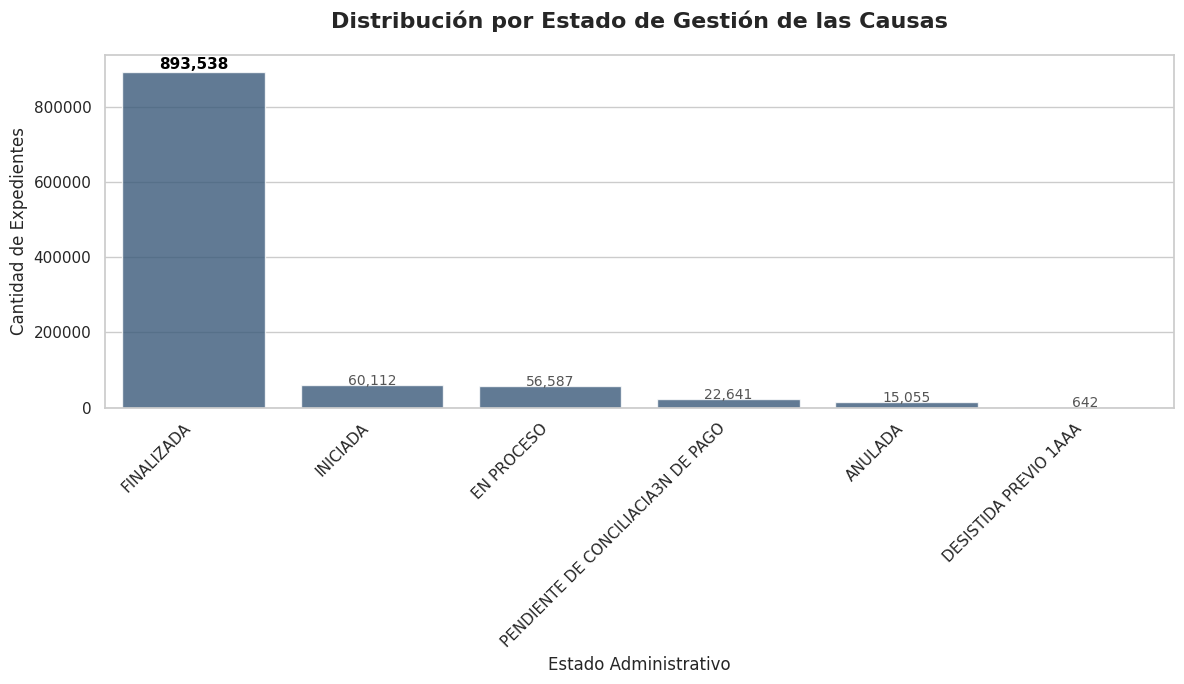

In [ ]:
# Preparación de datos
conteo_estados = df['estado'].value_counts()
valor_maximo_estado = conteo_estados.max()

# Estilo y tamaño
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Gráfico de barras verticales (Ejes invertidos)
# x = Categorías (Estado), y = Frecuencia (Cantidad)
ax = sns.barplot(x=conteo_estados.index, y=conteo_estados.values, color='#2E5984', alpha=0.8)

# Título y etiquetas
plt.title('Distribución por Estado de Gestión de las Causas', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Estado Administrativo', fontsize=12)
plt.ylabel('Cantidad de Expedientes', fontsize=12)

# Rotación de etiquetas para legibilidad
plt.xticks(rotation=45, ha='right')

# Etiquetas de datos verticales con negrita en el máximo
for i, v in enumerate(conteo_estados.values):
    if v == valor_maximo_estado:
        # Resaltado en negrita para el mayor
        ax.text(i, v + (v * 0.01), f'{int(v):,}',
                color='black', ha='center', fontweight='bold', fontsize=11)
    else:
        # Formato normal para el resto
        ax.text(i, v + (v * 0.01), f'{int(v):,}',
                color='#555555', ha='center', fontweight='normal', fontsize=10)

plt.tight_layout()
plt.show()

###**Porcentaje de Mediaciones Finalizadas**

In [ ]:
# Porcentaje de Mediaciones Finalizadas

total = len(df)
finalizadas = 893538
porcentaje_finalizadas = (finalizadas / total) * 100
print(f"El porcentaje de causas finalizadas es: {porcentaje_finalizadas:.1f}%")

El porcentaje de causas finalizadas es: 85.2%


###**Indicador de Resolutividad**

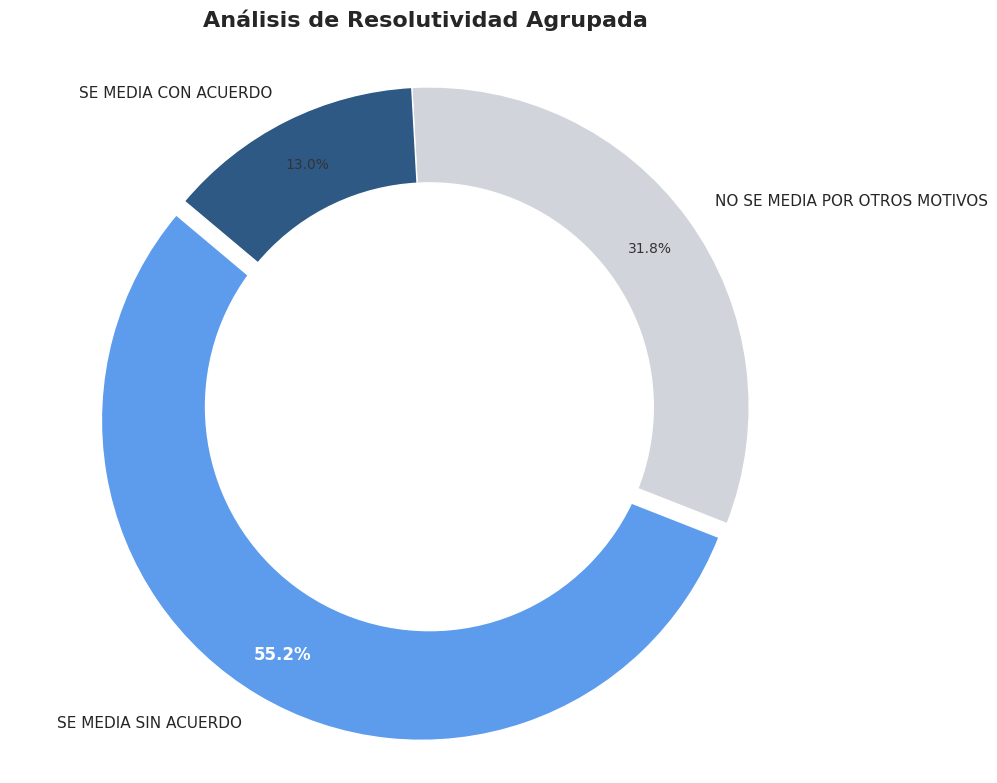

In [ ]:
# Definimos la lógica de agrupación (asegurando limpieza de datos)
def agrupar_resultados(valor):
    if pd.isna(valor):
        return "NO SE MEDIA POR OTROS MOTIVOS"

    texto = str(valor).upper().strip()

    if "SIN ACUERDO" in texto:
        return "SE MEDIA SIN ACUERDO"
    elif "CON ACUERDO" in texto:
        return "SE MEDIA CON ACUERDO"
    else:
        return "NO SE MEDIA POR OTROS MOTIVOS"

Aplicamos la función
df['resultado_agrupado'] = df['resultado_mediacion'].map(agrupar_resultados)

# Preparación de datos
conteo_agrupado = df['resultado_agrupado'].value_counts()
labels = conteo_agrupado.index
values = conteo_agrupado.values
max_val = values.max()

# Configuración de colores coherentes con los gráficos anteriores
# Usamos el azul principal, un celeste para el secundario y gris para 'otros'
colores_dict = {
    "SE MEDIA CON ACUERDO": "#2E5984",       # El azul de tus barras
    "SE MEDIA SIN ACUERDO": "#5D9CEC",       # Un celeste complementario
    "NO SE MEDIA POR OTROS MOTIVOS": "#D1D5DB" # Gris neutro profesional
}
colores = [colores_dict.get(label, "#D1D5DB") for label in labels]

# Creación del gráfico de torta (formato Dona)
plt.figure(figsize=(10, 8))

patches, texts, autotexts = plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colores,
    pctdistance=0.85,
    explode=[0.05 if v == max_val else 0 for v in values] # Resalta la porción mayor
)

# Título y formato de negrita solo para el máximo
plt.title('Análisis de Resolutividad Agrupada', fontsize=16, fontweight='bold', pad=20)

for i, a_text in enumerate(autotexts):
    if values[i] == max_val:
        a_text.set_fontweight('bold')
        a_text.set_fontsize(12)
        a_text.set_color('white') # Blanco para resaltar sobre el azul oscuro
    else:
        a_text.set_fontweight('normal')
        a_text.set_fontsize(10)
        a_text.set_color('#333333') # Gris oscuro para las otras porciones

Convertimos en formato dona
centro_circulo = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

plt.axis('equal')
plt.tight_layout()
plt.show()

##**Conclusiones y Hallazgos del Estudio**

####A partir del análisis cuantitativo realizado sobre el dataset del sistema MEPRE, se presentan las siguientes conclusiones fundamentales que caracterizan la dinámica de la mediación en el periodo estudiado:

####**Tendencia de la Demanda**: Se identifica un crecimiento sostenido en el ingreso de causas, alcanzando su **pico máximo operativo en el año 2023**. Las únicas retracciones en la serie histórica se registraron en **2016** y **2020**, esta última atribuible a la parálisis administrativa por la emergencia sanitaria.

####**Predominio Jurisdiccional y de Objeto**: El análisis de volumen confirma una concentración estructural en **el Fuero Civil, que abarca el 91.9%** del total de las mediaciones. Esta hegemonía es consistente con el hecho de que "**Daños y Perjuicios**" es el objeto predominante, lo que explica a su vez la alta **participación del ámbito privado (97%)**, debido a la naturaleza de los reclamos vinculados mayoritariamente al sector asegurador y la responsabilidad civil.

####**Dinámica de Cierre por Plazos Legales**: El dataset muestra que un **85.2%** de las causas (893,538 expedientes) se encuentran en estado **finalizado**. Este alto porcentaje de salida es un indicador de la **rigidez de los plazos perentorios fijados por ley**. La instancia prejudicial está diseñada como un proceso de tiempo acotado que debe concluir formalmente para habilitar la etapa siguiente, garantizando que el sistema no acumule stock de causas inactivas.

####**Indicador de Resolutividad Real**: Al contrastar el flujo de cierre con los resultados obtenidos, se observa que solo el **13%** de las mediaciones concluyen en un **acuerdo**. Esto permite concluir que el sistema es altamente eficiente en el **cumplimiento de los tiempos procesales (85.2% de finalización)**, pero posee una baja tasa de transformación de conflictos en acuerdos voluntarios (13%), funcionando predominantemente como un paso administrativo obligatorio previo a la vía judicial.


###**Bibliografía**

####**Ministerio de Justicia de la Nación**. Mediaciones Judiciales y Prejudiciales - Sistema MEPRE. Portal de Datos Abiertos de la República Argentina. Recuperado de: [https://datos.jus.gob.ar/dataset/mediaciones-prejudiciales-y-judiciales/archivo/109c6381-6397-4ed9-b175-f3c3ac48ab03]